In [1]:
import os, cv2, json, glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import sys, gc
sys.path.append("..")
from Network.index import ModelNetwork
from utils.index import showTile

In [2]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU

2.7.1+cu118
True
Quadro P6000


In [3]:
models = [f'model_{i}' for i in sorted([int(path.split('_')[-1]) for path in os.listdir('Backup')])]
models 

['model_1',
 'model_2',
 'model_3',
 'model_4',
 'model_5',
 'model_6',
 'model_7',
 'model_8',
 'model_9',
 'model_10',
 'model_11',
 'model_12',
 'model_13',
 'model_14',
 'model_15',
 'model_16',
 'model_17',
 'model_18',
 'model_19',
 'model_20',
 'model_21',
 'model_22',
 'model_23',
 'model_24',
 'model_25',
 'model_26',
 'model_27',
 'model_28',
 'model_29',
 'model_30',
 'model_31',
 'model_32',
 'model_33',
 'model_34',
 'model_35',
 'model_36',
 'model_37',
 'model_38',
 'model_39',
 'model_40',
 'model_41',
 'model_42',
 'model_43',
 'model_44',
 'model_45',
 'model_46',
 'model_47',
 'model_48',
 'model_49',
 'model_50',
 'model_51',
 'model_52',
 'model_53',
 'model_54',
 'model_55',
 'model_56',
 'model_57',
 'model_58',
 'model_59',
 'model_60',
 'model_61',
 'model_62']

In [4]:
modelId = models[-1]
dataset = 'dataset_wu'

baseDir    = f'Backup/{modelId}'
datasetDir = f'../Dataset/{dataset}'
print(baseDir)

if not os.path.exists(baseDir):
    print(f"Error: Model {modelId} not found at {baseDir}")
    
if not os.path.exists(datasetDir):
    print(f"Error: Dataset {dataset} not found at {datasetDir}")

Backup/model_62


In [5]:
with open(f'{baseDir}/info.json', 'r', encoding='utf-8') as f:
    modelInfo = json.load(f)

modelOptions = modelInfo.get('model', {})
print("Model Options:")
print(json.dumps(modelOptions, indent=4))

network   = ModelNetwork(**modelOptions)
modelData = torch.load(f'{baseDir}/model.pth')

network.model.load_state_dict(modelData['model'])
network.model.eval()
print(f"Weights from {modelId} loaded successfully!")

Model Options:
{
    "network": "unet3d_v2",
    "img_size": [
        128,
        128,
        128
    ],
    "classes": 1,
    "channels": 1,
    "dropout": 0.1,
    "num_filters": 16,
    "lr": 0.001
}


Weights from model_62 loaded successfully!


In [6]:
imgPaths  = sorted(glob.glob(f'{datasetDir}/images/*.npy'))
maskPaths = sorted(glob.glob(f'{datasetDir}/masks/*.npy'))

if len(imgPaths) == 0 or len(maskPaths) == 0:
    print(f"No data found at {datasetDir}/images or masks.")

dfPredict = pd.DataFrame({
    'img_path': imgPaths,
    'mask_path': maskPaths
})
print(f"Total samples in {dataset}: {len(dfPredict)}")

Total samples in dataset_wu: 220


In [7]:
class PredictDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row  = self.df.iloc[index]
        img  = np.load(row.img_path).astype(np.float32)
        mask = np.load(row.mask_path).astype(np.float32)

        img_tensor  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.long).unsqueeze(0)
        return (img_tensor, mask_tensor)


predictDataset = PredictDataset(dfPredict)
predictLoader  = DataLoader(
    predictDataset, 
    batch_size=1,
    shuffle=False, 
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

In [8]:
def computeIoU(network, loader):
    network.model.eval()
    network.iou.reset()

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Computing IoU"):
            imgs, masks = imgs.to(network.device), masks.to(network.device)
            logits = network.model(imgs)
            
            if network.multiclass:
                preds  = torch.argmax(logits, dim=1)
                target = masks.squeeze(1) if masks.dim() == 5 else masks
                network.iou.update(preds, target)
            else:
                preds = (torch.sigmoid(logits) > 0.5)
                network.iou.update(preds, masks.int())
                
    iouValue = network.iou.compute().item()
    return iouValue


totalIoU = computeIoU(network, predictLoader)
print(f"\nMean IoU on {dataset}: {totalIoU:.4f}")

Computing IoU:   0%|                                                                                     | 0/220 [00:00<?, ?it/s]

Computing IoU:   0%|▎                                                                            | 1/220 [00:00<02:45,  1.33it/s]

Computing IoU:   1%|▋                                                                            | 2/220 [00:01<02:06,  1.73it/s]

Computing IoU:   1%|█                                                                            | 3/220 [00:01<01:51,  1.94it/s]

Computing IoU:   2%|█▍                                                                           | 4/220 [00:02<01:47,  2.02it/s]

...

Computing IoU:  99%|██████████████████████████████████████████████████████████████████████████▎| 218/220 [01:39<00:00,  2.17it/s]

Computing IoU: 100%|██████████████████████████████████████████████████████████████████████████▋| 219/220 [01:40<00:00,  2.17it/s]

Computing IoU: 100%|███████████████████████████████████████████████████████████████████████████| 220/220 [01:40<00:00,  2.18it/s]

Computing IoU: 100%|███████████████████████████████████████████████████████████████████████████| 220/220 [01:40<00:00,  2.18it/s]


Mean IoU on dataset_wu: 0.5573


In [9]:
synthetic = json.loads(open('../Dataset/dataset_synthetic/synthetic.json', 'r').read())
synthetic

{'layerRange': [52, 148],
 'layerThickness': [1, 4],
 'foldCount': [17, 38],
 'foldSigma': [16, 47],
 'foldAmplitude': [-34, 10],
 'foldDamping': 1.4839720010963449,
 'foldBaseShift': [-0.6556346746377661, 3.887919457394822],
 'shearOffset': [-9.165265503783951, 2.572286201623045],
 'shearGradient': [-0.10383601481734801, 0.011202304867549955],
 'faultCount': [5, 12],
 'faultThrow': [14, 30],
 'faultDipAngle': [62, 79],
 'faultRoughness': 6.843278108071441,
 'faultRoughSigma': 9.283170132142946,
 'faultDecaySigma': [37, 78],
 'faultZoneWidth': 0.559811930465628,
 'faultThreshold': 0.5163895664671108,
 'faultCurveProb': 0.3926709793365326,
 'faultCurveMax': 6.577597882371399,
 'waveletFreq': [84, 93],
 'waveletDuration': 0.10067674379379399,
 'waveletDt': 0.001491193710545622,
 'noiseLevel': [0.012032830147561074, 0.5794113420534458]}

In [10]:
path = f'../Searcher/database/{modelId}'
os.makedirs(path, exist_ok=True)

with open(f'{path}/info.json', 'w', encoding='utf-8') as file:
    json.dump({
        'model':  modelId,
        'iou_wu': totalIoU,
        'config': synthetic
    },
    file, ensure_ascii=False, indent=4)

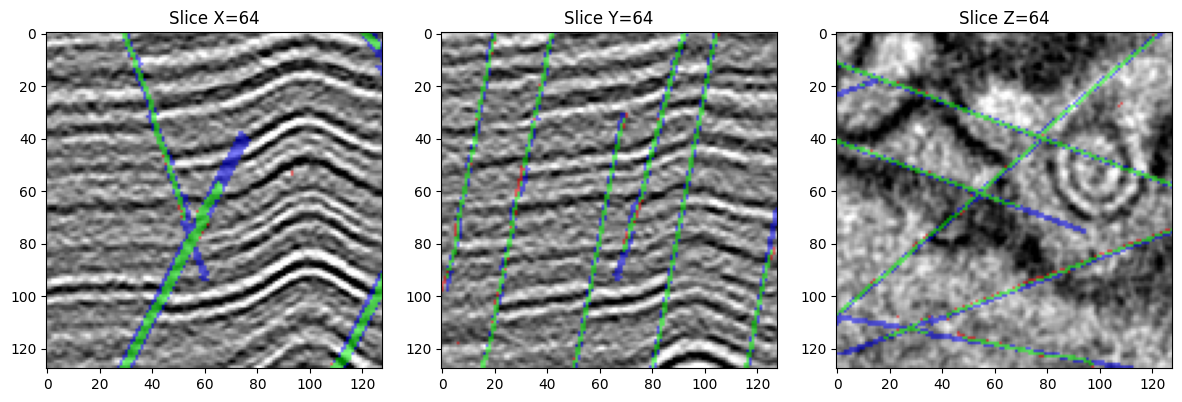

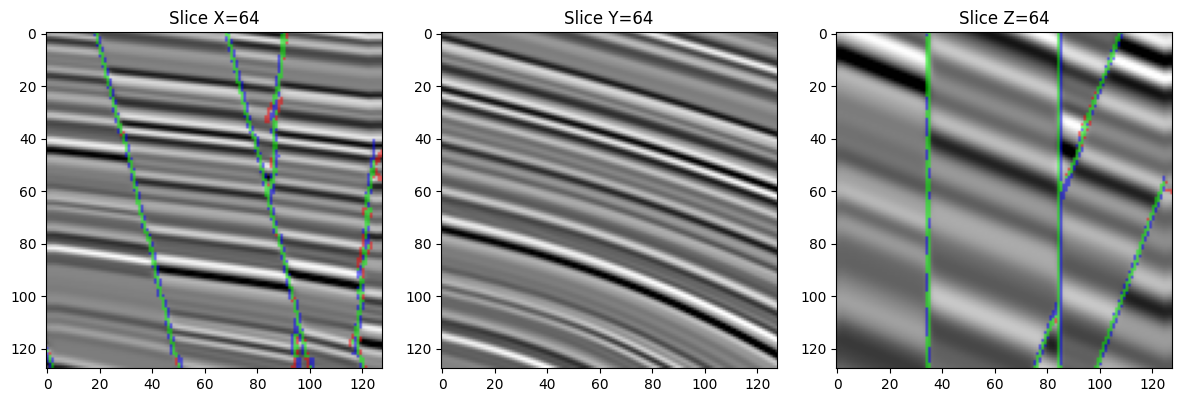

In [11]:
def plotPrediction(index, dataset=predictDataset, network=network, alpha=0.5, savePath=None):
    img_tensor, mask_tensor = dataset[index]
    network.model.eval()

    with torch.no_grad():
        img_batch = img_tensor.unsqueeze(0).to(network.device)
        logits    = network.model(img_batch)
        pred = torch.argmax(logits, dim=1).squeeze() if network.multiclass else (torch.sigmoid(logits) > 0.5).squeeze().int()

    img_np  = img_tensor.squeeze().cpu().numpy()
    mask_np = mask_tensor.squeeze().cpu().numpy()
    pred_np = pred.cpu().numpy()

    imgNorm = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    imgRgb  = np.stack((imgNorm, imgNorm, imgNorm), axis=-1)
    overlay = imgRgb.copy()
    is_gt   = (mask_np > 0)
    is_pred = (pred_np > 0)
    inters  = (is_gt & is_pred)   # Acertos / Interseção

    overlay[is_gt]   = [0, 0, 255]  # Azul para o Ground Truth (Falhas reais não detectadas)
    overlay[is_pred] = [255, 0, 0]  # Vermelho para a Predição (Falsos alarmes)
    overlay[inters]  = [0, 255, 0]  # verde onde Predição e GT convergem (Acertos)

    result = (imgRgb * (1 - alpha) + overlay * alpha).astype(np.uint8)
    showTile(img=result, save=savePath)
        

for i in range(min(len(predictDataset), 2)):
    plotPrediction(index=i)